In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
data_tvbs公路 = pd.read_csv('tvbs_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1177
data_tvbs改 = pd.read_csv('tvbs_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #380
data_自由公路 = pd.read_csv('自由_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #3959
data_自由改 = pd.read_csv('自由_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #2598
data_ettoday公路 = pd.read_csv('ettoday_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1702
data_ettoday改 = pd.read_csv('ettoday_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1057


data = pd.concat([data_tvbs公路, data_tvbs改, data_自由公路, data_自由改, data_ettoday公路, data_ettoday改], ignore_index=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10839 entries, 0 to 10838
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        10839 non-null  object
 1   Context      10839 non-null  object
 2   PublishTime  10839 non-null  object
dtypes: object(3)
memory usage: 254.2+ KB


In [87]:
data['Context'].duplicated().sum()

275

In [88]:
data = data[~data['Context'].duplicated()].reset_index(drop=True)

In [89]:
data.head(10)

,Title,Context,PublishTime
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025/06/12 15:50
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025/06/08 20:53
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025/05/21 13:10
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025/05/21 12:49
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025/05/20 17:11
5,駕駛注意！蘇花中仁隧道南下線施工 5／13起「封閉17天」,用路人注意！為進行排水改善並復原路面施工，台9線蘇花改「中仁隧道南下線」自今（13）日上午起...,2025/05/13 11:56
6,清明連假首日爆出遊潮！蘇花恐塞14小時 桃機估湧14.5萬人,清明4天連假即將到來，交通部公路局預估本次連假車潮將以掃墓祭祖及觀光旅遊為主，省道主要幹道及...,2025/04/01 09:45
7,騎士檢舉違規遭退件 控警消極未通知補件,上個月初，有機車騎士在蘇花公路，差點被對向一輛跨越雙黃線的休旅車撞上，騎士隔天上網檢舉，不過...,2025/01/03 18:36
8,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024/12/02 14:30
9,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024/11/02 17:46


In [90]:
data['PublishTime'] = pd.to_datetime(data['PublishTime'], format='%Y/%m/%d %H:%M', errors='coerce')

In [91]:
data['PublishYear'] = data['PublishTime'].dt.to_period('Y').astype(str)

In [92]:
data

,Title,Context,PublishTime,PublishYear
0,地震、豪雨夾擊！中橫落石阻斷明搶通 蘇花公路夜間恐預警封閉,受到昨（11）日東部規模6.4地震及熱帶低壓降雨影響，中橫公路台8線157.7k豁然亭路段，...,2025-06-12 15:50:00,2025
1,花蓮暴雨頻傳災情！7學生砂婆噹溪「戲水受困」,花蓮地區下午到晚上期間，大雨與雷聲不間斷，有7名學生到知名景點砂婆噹戲水，返程時，遇到溪水暴...,2025-06-08 20:53:00,2025
2,豪雨重創花蓮！徐榛蔚喊話賴清德「不要搭專機」 體驗交通之苦,近日豪雨影響，花蓮北上鐵公路再度中斷，導致交通受阻，縣長徐榛蔚今天攜手多位議員及觀光產業界，...,2025-05-21 13:10:00,2025
3,3天2中斷！台鐵單線雙向 花端午訂房剩3.5成,台鐵北迴線，受到大雨影響，兩度雙向中斷無法通行，昨天連蘇花公路都受影響，台鐵宣布在今天清晨4...,2025-05-21 12:49:00,2025
4,鐵路公路雙癱瘓！台鐵和仁段又豪雨停駛 蘇花崇德段只出不進,花蓮縣18日下午受到對流雲系發展旺盛影響，下起傾盆大雨，導致台鐵「和仁=崇德」遭土石流淹沒軌...,2025-05-20 17:11:00,2025
...,...,...,...,...
10559,蘇花改火藥庫遭土石流沖毀 留守人員失蹤,地方中心／花蓮報導\n蘇拉颱風挾帶暴雨沖刷花蓮縣秀林鄉，公路單位設於山區儲放工程火藥的龍崎分...,NaT,NaT
10560,宜縣長視察南澳 預防蘇花改通車破壞原住民文化,我們想讓你知道…保存原住民文化很重要!\n地方中心／宜蘭報導\n2015年蘇花改通車以後，位...,NaT,NaT
10561,馬英九花蓮掃街固盤 允諾太魯閣號增班,我們想讓你知道…蔡前腳走，馬跟進掃花蓮，擺明就是固盤啦\n政治中心／花蓮報導\n馬英九總統3...,NaT,NaT
10562,馬英九：十年內加入TPP,我們想讓你知道…國、民兩黨都開始打TPP牌了。\n政治中心／綜合報導\n總統馬英九22日表示...,NaT,NaT


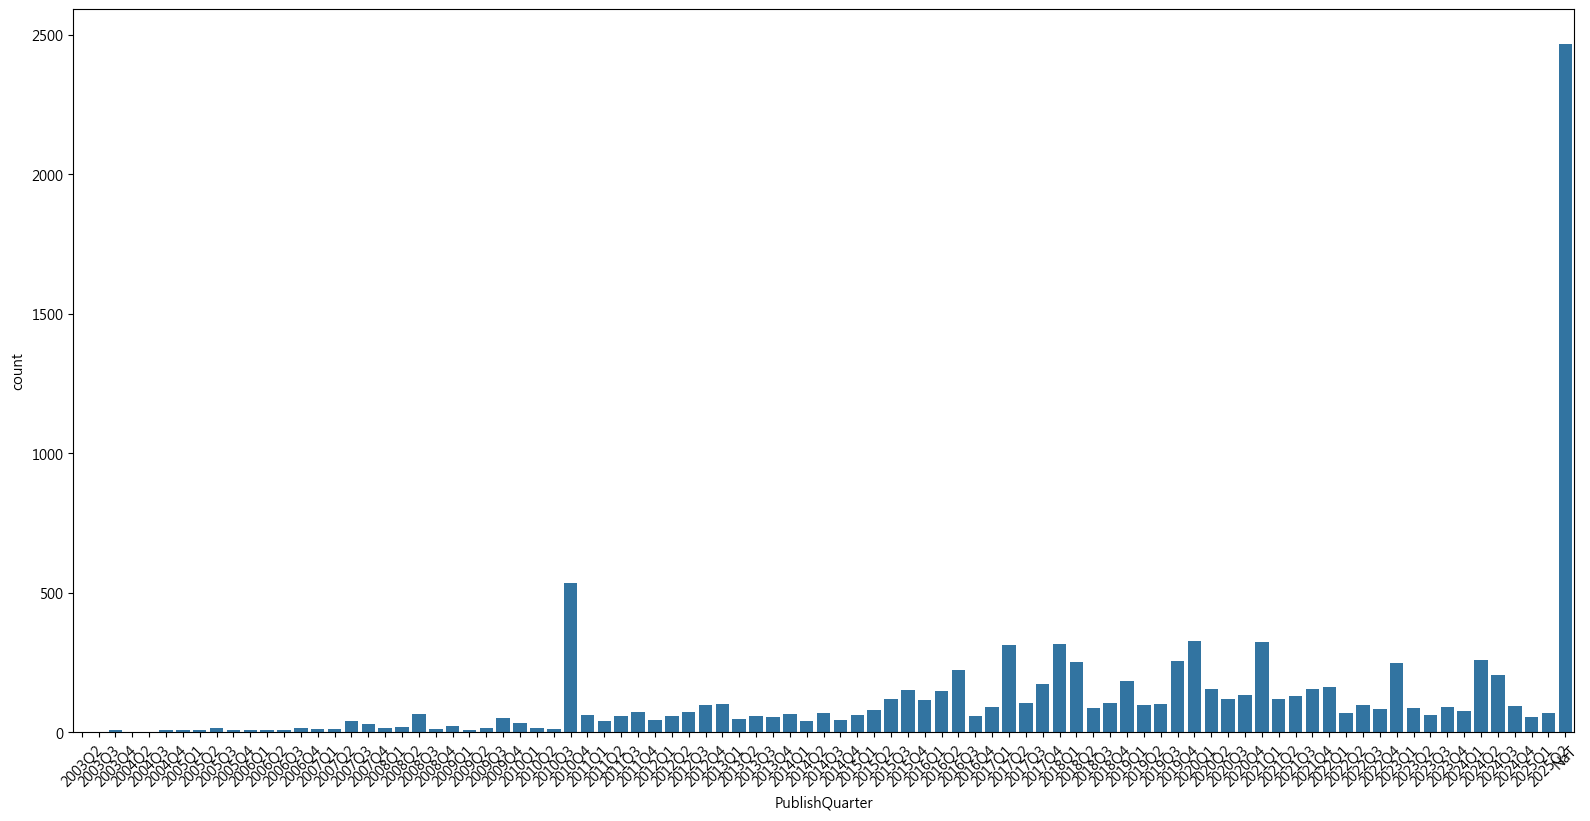

In [93]:
data['PublishQuarter'] = data['PublishTime'].dt.to_period('Q').astype(str)
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [94]:
data = data[(pd.to_datetime(data['PublishTime']) >= pd.Timestamp('2015-01-01')) 
            & (pd.to_datetime(data['PublishTime']) <= pd.Timestamp('2024-12-31'))].reset_index(drop=True)


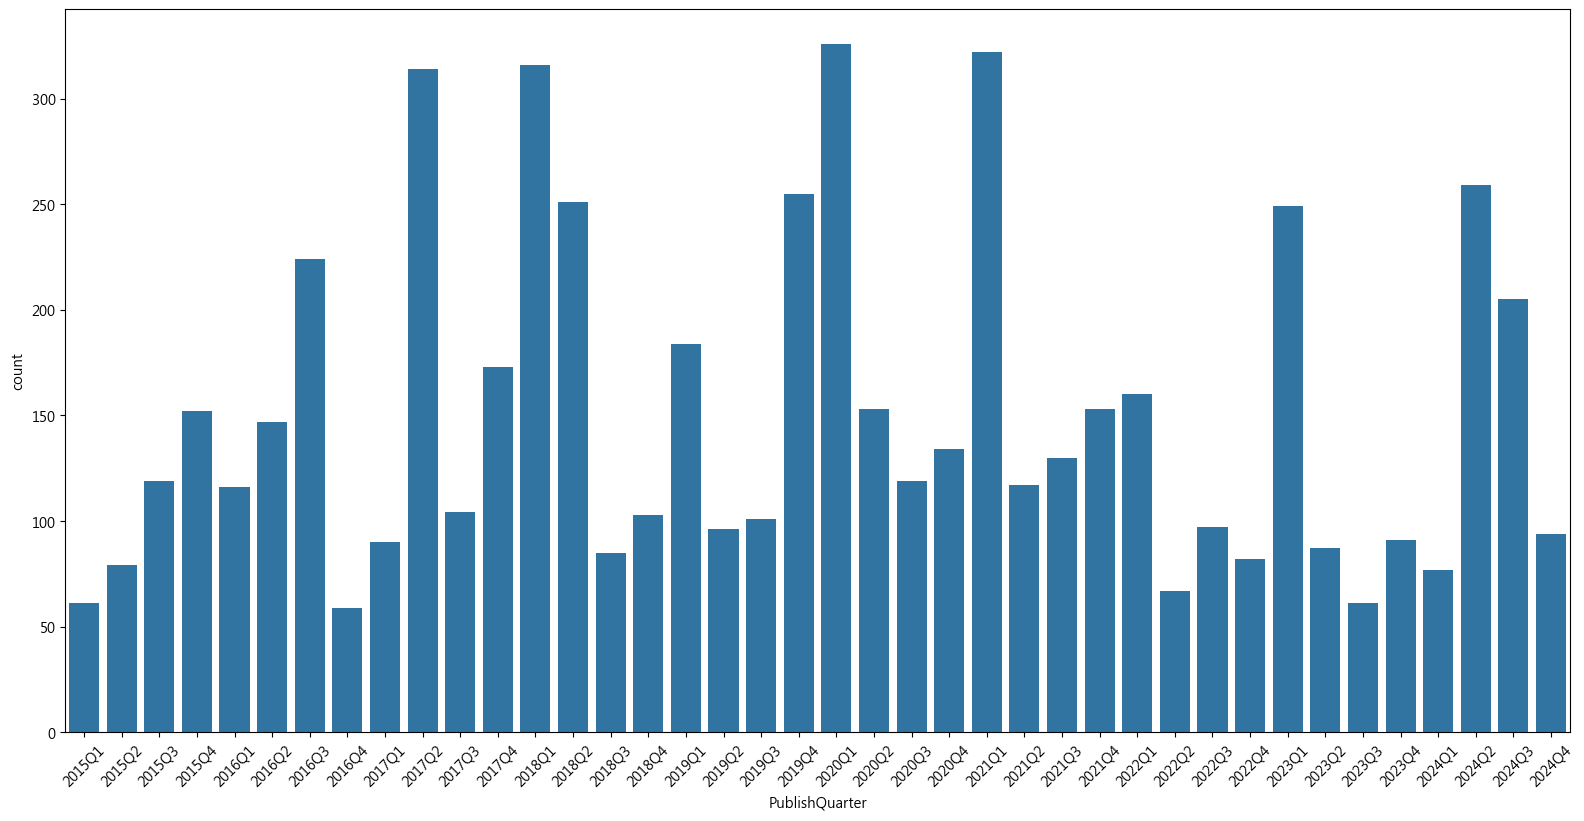

In [95]:
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [96]:
text_all = '\n'.join(data['Context'].dropna())

In [97]:
import jieba, re, string

In [98]:
fullwidth_punctuation = "，。！？：；「」『』（）〔〕【】《》—…～‧、．／"
all_punct = string.punctuation + fullwidth_punctuation
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    
    # 刪除「首次上稿 時間 更新時間 時間」格式（容許冒號遺失）
    text = re.sub(r'首次上稿\s?\d{0,2}[:：]?\d{0,2}?\s*更新時間\s?\d{0,2}[:：]?\d{0,2}', '', text)
    text = re.sub(r'首次上稿\s*', '', text)
    text = re.sub(r'更新時間\s*', '', text)

    # 刪除「〔記者XXX／XXX報導〕」格式
    text = re.sub(r'〔記者.{1,10}／.{1,10}報導〕', '', text)

    # 移除「記者XXX／XXX報導」無括號變形
    text = re.sub(r'記者.{1,10}[／／]{1}.{1,10}報導', '', text)

    text = text.translate(str.maketrans('', '', all_punct))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text) # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 刪網址
    text = re.sub(r'<.*?>+', '', text) # 刪 HTML tag
    text = re.sub(r'\n', ' ', text) # 換行→空白
    # text = re.sub(r'\w*\d\w*', ' ', text) # 含數字詞
    text = re.sub(r'\d+', ' ', text) # 數字
    text = re.sub(r'\s+', ' ', text).strip() # 連續空白
    return text
data["Cleaned_Context"] = data["Context"].apply(clean_text)
data.head(10)

,Title,Context,PublishTime,PublishYear,PublishQuarter,Cleaned_Context
0,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024-12-02 14:30:00,2024,2024Q4,今 日中午 時許宜蘭縣南澳鄉台九丁線 公里處南下發生火燒車意外車上 歲趙姓男駕駛與姊姊從桃園...
1,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024-11-02 17:46:00,2024,2024Q4,康芮颱風侵襲帶來許多災情在蘇花公路匯德隧道北口發生土石流高達 萬 千立方公尺的土石掩埋道路公...
2,蘇花匯德隧道提前搶通 和仁＝崇德2時段開放通行,受到康芮颱風影響，蘇花路廊台9線161.3k匯德隧道北口日前發生坍方，造成道路及隧道洞口遭土...,2024-11-02 12:44:00,2024,2024Q4,受到康芮颱風影響蘇花路廊台 線 k匯德隧道北口日前發生坍方造成道路及隧道洞口遭土石掩埋對此公...
3,「康芮」釀土石流！淹卓溪部落 住戶崩潰,康芮颱風重創山區，東部及阿里山的鐵路甚至還有蘇花公路都受到影響，相關單位在颱風警報解除後，加...,2024-11-01 21:52:00,2024,2024Q4,康芮颱風重創山區東部及阿里山的鐵路甚至還有蘇花公路都受到影響相關單位在颱風警報解除後加快速度...
4,無法去碧候溫泉！康芮過境 宜蘭南澳路基掏空,康芮颱風過境後，宜蘭災損嚴重，除了農作物番茄、蒜苗幾乎泡湯，更慘的是蘇花公路南澳鄉路段，上次...,2024-11-01 13:35:00,2024,2024Q4,康芮颱風過境後宜蘭災損嚴重除了農作物番茄蒜苗幾乎泡湯更慘的是蘇花公路南澳鄉路段上次凱米颱風造...
5,康芮重創蘇花鐵公路中斷 花東疏運啟動「凱旋3號」急支援,康芮颱風重創台灣，造成台鐵北迴線崇德到和仁、花東線中斷，交通部長陳世凱於今（1）日視察風災後...,2024-11-01 11:37:00,2024,2024Q4,康芮颱風重創台灣造成台鐵北迴線崇德到和仁花東線中斷交通部長陳世凱於今 日視察風災後交通運輸情...
6,康芮重創！蘇花匯德隧道「坍方逾1萬立方公尺」驚人畫面曝,受颱風「康芮」強風降雨影響，台9線蘇花路廊有多處落石坍方、土石流災情，161.3公里處、匯德...,2024-11-01 10:20:00,2024,2024Q4,受颱風康芮強風降雨影響台 線蘇花路廊有多處落石坍方土石流災情 公里處匯德隧道北口又被土石淹沒...
7,南方澳掀巨浪！台七丙土石坍塌實施交管,颱風籠罩台灣本島，宜蘭地區風雨也漸漸增強，一早南方澳海邊掀起巨浪，一旁的蘇花公路蘇澳段也從3...,2024-10-31 13:35:00,2024,2024Q4,颱風籠罩台灣本島宜蘭地區風雨也漸漸增強一早南方澳海邊掀起巨浪一旁的蘇花公路蘇澳段也從 日晚間...
8,溪水暴漲玉里便橋封閉 男繞道洗腎車拋錨,蘇花公路崇德路段，今日(10月3日)清晨又發生土石流，預計下午才能搶通，而花蓮玉里鎮也有便橋...,2024-10-03 12:40:00,2024,2024Q4,蘇花公路崇德路段今日 月 日清晨又發生土石流預計下午才能搶通而花蓮玉里鎮也有便橋封閉洗腎患者...
9,蘇花公路崇德和仁段「下午僅開2時間」 18時預警性封路,中颱山陀兒持續緩慢逼近，各地風雨預測也隨之延後及下修，對此公路局表示，受外圍環流影響，今（2...,2024-10-02 13:47:00,2024,2024Q4,中颱山陀兒持續緩慢逼近各地風雨預測也隨之延後及下修對此公路局表示受外圍環流影響今 日蘇花公路...


In [99]:
synonym_dict = {'花蓮縣':'花蓮', '花蓮市':'花蓮', '舊蘇花':'蘇花公路', '蘇花':'蘇花公路',
                '蘇花改':'蘇花改', '蘇花高':'蘇花高', '蘇花安':'蘇花安', '台九':'台九線', '台九丁線':'台九線'
}

for word in set(list(synonym_dict.keys()) + list(synonym_dict.values())):
    jieba.add_word(word)

with open('停用詞-繁體中文.txt', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f)

def tokenize(text, synonym_dict, stopwords):
    if pd.isna(text):
        return []
    tokens = list(jieba.cut(text))
    normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
    filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
    return filter_tokens

data['Tokens'] = data['Cleaned_Context'].apply(lambda x: tokenize(x, synonym_dict, stopwords))
print(list(jieba.cut("蘇花改是蘇花公路的重要替代路段")))


['蘇花改', '是', '蘇花公路', '的', '重要', '替代', '路段']


In [100]:
data[['Title', 'Tokens']].head(10)


,Title,Tokens
0,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,"[中午, 時許, 宜蘭縣, 南澳, 台九線, 公里, 南下, 生火, 燒車, 意外, 車上,..."
1,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,"[康芮, 侵襲, 帶來, 許多, 災情, 蘇花公路, 匯德, 隧道, 北口, 發生, 土石,..."
2,蘇花匯德隧道提前搶通 和仁＝崇德2時段開放通行,"[受到, 康芮, 風影響, 蘇花公路, 廊台, 匯德, 隧道, 北口, 日前, 發生, 坍方..."
3,「康芮」釀土石流！淹卓溪部落 住戶崩潰,"[康芮, 風重, 創山區, 東部, 阿里山, 鐵路, 蘇花公路, 受到, 影響, 相關, 單..."
4,無法去碧候溫泉！康芮過境 宜蘭南澳路基掏空,"[康芮, 風過, 境後宜蘭, 災損, 嚴重, 作物, 番茄, 蒜苗, 泡湯, 更慘, 蘇花公..."
5,康芮重創蘇花鐵公路中斷 花東疏運啟動「凱旋3號」急支援,"[康芮, 風重, 創台灣, 造成, 台鐵北, 崇德, 仁花, 東線, 中斷, 交通部, 世凱..."
6,康芮重創！蘇花匯德隧道「坍方逾1萬立方公尺」驚人畫面曝,"[風康, 芮強, 降雨, 影響, 蘇花公路, 路廊, 多處, 落石, 坍方, 土石, 流災情..."
7,南方澳掀巨浪！台七丙土石坍塌實施交管,"[風籠, 台灣, 本島, 宜蘭, 地區, 風雨, 漸漸, 增強, 一早, 南方澳, 海邊, ..."
8,溪水暴漲玉里便橋封閉 男繞道洗腎車拋錨,"[蘇花公路, 崇德, 路段, 今日, 清晨, 發生, 土石, 預計, 下午, 搶通, 花蓮,..."
9,蘇花公路崇德和仁段「下午僅開2時間」 18時預警性封路,"[山陀兒, 持續, 緩慢, 逼近, 各地, 風雨, 預測, 隨之延後及, 公路局, 表示, ..."


In [101]:
data

,Title,Context,PublishTime,PublishYear,PublishQuarter,Cleaned_Context,Tokens
0,赴花蓮玩出事了！小客車舊蘇花公路起火 姐弟倆急跳車逃命,今（2）日中午12時許，宜蘭縣南澳鄉台九丁線46.9公里處南下，發生火燒車意外，車上49歲趙...,2024-12-02 14:30:00,2024,2024Q4,今 日中午 時許宜蘭縣南澳鄉台九丁線 公里處南下發生火燒車意外車上 歲趙姓男駕駛與姊姊從桃園...,"[中午, 時許, 宜蘭縣, 南澳, 台九線, 公里, 南下, 生火, 燒車, 意外, 車上,..."
1,蘇花搶通！上萬立方公尺土石掩埋 7怪手搶修,康芮颱風侵襲帶來許多災情，在蘇花公路匯德隧道北口，發生土石流，高達1萬2千立方公尺的土石掩埋...,2024-11-02 17:46:00,2024,2024Q4,康芮颱風侵襲帶來許多災情在蘇花公路匯德隧道北口發生土石流高達 萬 千立方公尺的土石掩埋道路公...,"[康芮, 侵襲, 帶來, 許多, 災情, 蘇花公路, 匯德, 隧道, 北口, 發生, 土石,..."
2,蘇花匯德隧道提前搶通 和仁＝崇德2時段開放通行,受到康芮颱風影響，蘇花路廊台9線161.3k匯德隧道北口日前發生坍方，造成道路及隧道洞口遭土...,2024-11-02 12:44:00,2024,2024Q4,受到康芮颱風影響蘇花路廊台 線 k匯德隧道北口日前發生坍方造成道路及隧道洞口遭土石掩埋對此公...,"[受到, 康芮, 風影響, 蘇花公路, 廊台, 匯德, 隧道, 北口, 日前, 發生, 坍方..."
3,「康芮」釀土石流！淹卓溪部落 住戶崩潰,康芮颱風重創山區，東部及阿里山的鐵路甚至還有蘇花公路都受到影響，相關單位在颱風警報解除後，加...,2024-11-01 21:52:00,2024,2024Q4,康芮颱風重創山區東部及阿里山的鐵路甚至還有蘇花公路都受到影響相關單位在颱風警報解除後加快速度...,"[康芮, 風重, 創山區, 東部, 阿里山, 鐵路, 蘇花公路, 受到, 影響, 相關, 單..."
4,無法去碧候溫泉！康芮過境 宜蘭南澳路基掏空,康芮颱風過境後，宜蘭災損嚴重，除了農作物番茄、蒜苗幾乎泡湯，更慘的是蘇花公路南澳鄉路段，上次...,2024-11-01 13:35:00,2024,2024Q4,康芮颱風過境後宜蘭災損嚴重除了農作物番茄蒜苗幾乎泡湯更慘的是蘇花公路南澳鄉路段上次凱米颱風造...,"[康芮, 風過, 境後宜蘭, 災損, 嚴重, 作物, 番茄, 蒜苗, 泡湯, 更慘, 蘇花公..."
...,...,...,...,...,...,...,...
6007,蘇花改貫通石助不孕夫妻一舉得男,〔記者朱則瑋／宜蘭報導〕彰化縣1對蕭姓夫婦想要孩子，曾嘗試3次人工受孕，但15年來無消無息，...,2015-03-17 15:41:00,2015,2015Q1,彰化縣 對蕭姓夫婦想要孩子曾嘗試 次人工受孕但 年來無消無息醫生也判定恐一輩子無法懷孕去年 ...,"[彰化, 蕭姓, 夫婦, 想要, 孩子, 曾嘗試, 人工受孕, 消無息, 醫生, 判定, 恐..."
6008,全台原民放狼煙 爭取自決權,〔記者陳炳宏、邱芷柔、游明金／綜合報導〕「二二八不只是連假，是讓更多人看見、反思政府不合理、...,2015-03-01 06:00:00,2015,2015Q1,記者陳炳宏邱芷柔游明金綜合報導二二八不只是連假是讓更多人看見反思政府不合理不正確政策的時候選...,"[記者陳炳宏, 邱芷柔, 游明金, 綜合, 報導, 二二八, 連假, 反思, 政府, 不合理..."
6009,春節、二二八連假 國道客運停駛全程車,〔記者江志雄／羅東報導〕公路總局制定宜蘭縣春節及二二八連假交通疏運計畫，以國道五號、蘇花公路...,2015-02-05 06:00:00,2015,2015Q1,公路總局制定宜蘭縣春節及二二八連假交通疏運計畫以國道五號蘇花公路為防塞熱區春節期間國道客運羅...,"[公路, 總局, 制定, 宜蘭縣, 春節, 二二八, 連假, 交通, 疏運計畫, 以國道, ..."
6010,包商倒閉 工程延後 蘇花改最快108年通車,〔記者游太郎／花蓮報導〕蘇花公路改善工程處昨證實，位於花蓮縣境內的「中仁隧道新建工程」，承包...,2015-01-30 06:00:00,2015,2015Q1,蘇花公路改善工程處昨證實位於花蓮縣境內的中仁隧道新建工程承包商因財務因素終止契約正重新招標中...,"[蘇花公路, 改善, 工程, 昨證, 實位, 花蓮, 境內, 中仁, 隧道, 新建, 工程,..."


In [102]:
from collections import Counter
all_tokens = [token for tokens in data['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)
top_tf = word_freq.most_common(30)

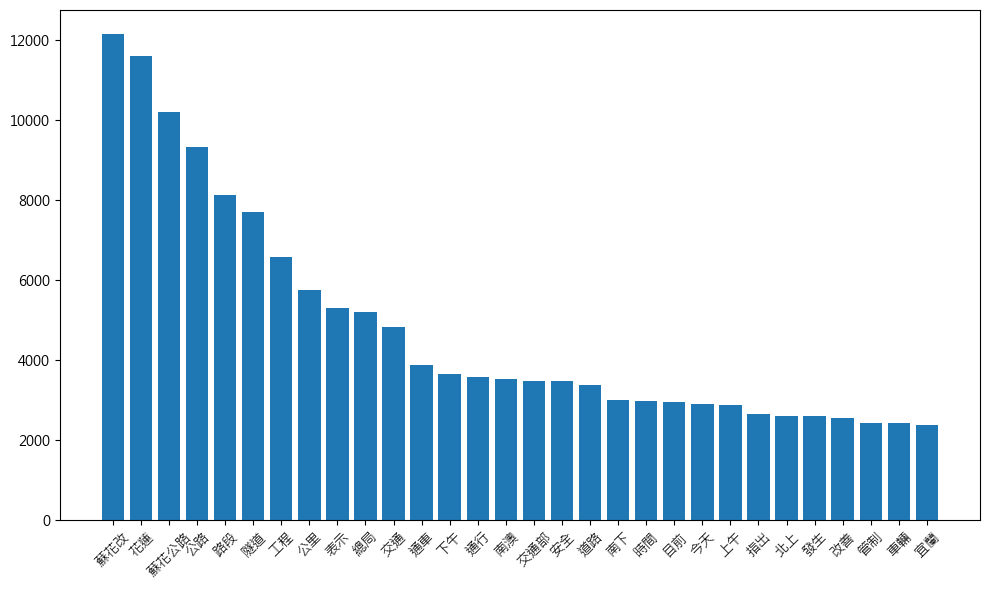

In [103]:
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
words, freqs = zip(*top_tf)
plt.figure(figsize=(10, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
data['Joined_Tokens'] = data['Tokens'].apply(lambda x: ' '.join(x))
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(data['Joined_Tokens'])
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


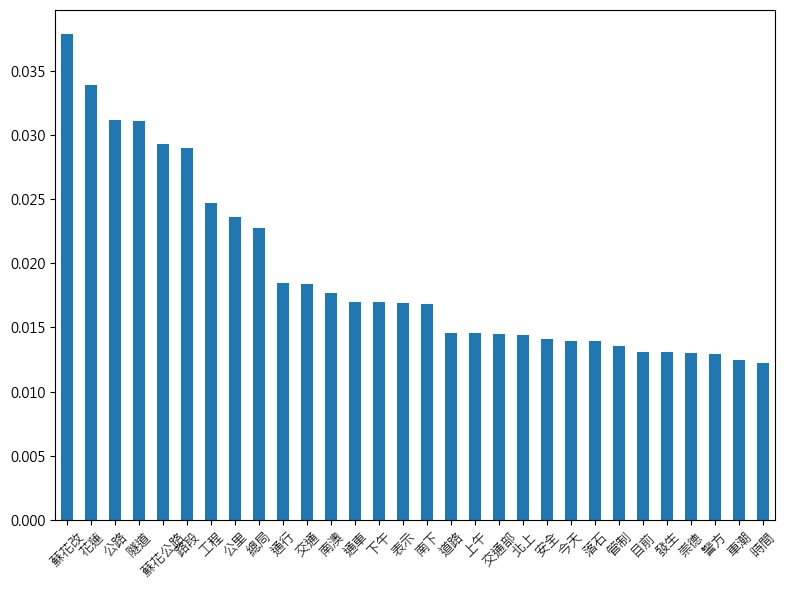

In [105]:
mead_tfidf = tfidf_df.mean().sort_values(ascending=False)
top_tfidf = mead_tfidf.head(30)
top_tfidf.plot(kind='bar', figsize=(8, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [106]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [107]:
vectorizer = CountVectorizer()
count_matrix = vectorizer.fit_transform(data['Joined_Tokens'])
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda_matrix = lda.fit_transform(count_matrix)

data['Topic'] = lda_matrix.argmax(axis=1) +1

In [108]:
def display_topics(model, feature_names, topn=30):
    for index, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
        print(f'主題 {index+1}: {'、'.join(top_words)}')
display_topics(lda, vectorizer.get_feature_names_out())

主題 1: 台灣、機車、一個、希望、表示、中國、安全、經濟、認為、社會、調查、相關、時間、方式、問題、今年、看到、國家、蘇花公路、政府、能夠、已經、進行、總統、重要、國際、應該、發現、要求、需要
主題 2: 隧道、蘇花改、公里、公路、超速、蘇花公路、測速、安全、警方、道路、花蓮、總局、路段、執法、區間、工程、公尺、車道、速限、南澳、表示、通車、低速、仁水、造成、交通、精油、夏日、事故、用路
主題 3: 蘇花改、路段、公路、隧道、蘇花公路、總局、工程、公里、南下、通車、下午、北上、交通、表示、車潮、連假、上午、通行、車流、壅塞、國道、管制、時段、蘇澳、預估、時間、流量、假期、路廊、南澳
主題 4: 花蓮、公路、蘇花公路、路段、落石、封閉、坍方、土石、下午、道路、通行、總局、地震、預警性、發生、目前、上午、表示、崇德、航班、取消、台北、影響、管制、南澳、公路局、今天、公里、造成、時間
主題 5: 花蓮、蘇花改、遺址、表示、工程、觀光、金門、台灣、隧道、交通部、賀陳旦、環島、通車、政府、蘇花公路、交通、台北、消防、漢本、完成、宜蘭、公尺、日本、打造、兩岸、消防局、首座、救災、時間、今年
主題 6: 美食、台北、咖啡、playing、報導、完整、推出、提供、體驗、住宿、旅遊、新加坡、遊客、新開店、美景、活動、日本、套餐、海岸、台灣、結合、壽司、牛排、打造、海洋、南澳、景點、設計、集團、海灘
主題 7: 蘇花公路、警方、發生、駕駛、公里、花蓮、事故、遊覽車、現場、造成、車禍、車輛、砂石、新聞、騎士、男子、發現、意外、山壁、隧道、tvbs、死亡、一輛、好友、原因、受傷、醫院、快點、加入、line
主題 8: 花蓮、蘇花改、工程、交通、計畫、交通部、改善、建設、地方、安全、蘇花安、政府、希望、立委、評估、縣府、表示、行政院、完工、規劃、問題、宜蘭、中央、南澳、完成、進行、通車、蘇花公路、和平、提出
主題 9: 公路、花蓮、蘇花改、總局、客運、表示、安全、交通部、工程、車輛、通車、通行、遊覽車、台北、事故、蘇花公路、目前、大貨車、申請、放大、地震、轉運站、時間、今年、運輸、隧道、完成、客車、路線、南港
主題 10: 花蓮、觀光、蘇花改、旅遊、地區、飯店、住房、遊客、旅客、工程、疫情、影響、民眾、北部、隧道、連假、人次、觀音、貫通石、台灣、業者、表示、宜蘭、民宿、各地、貫通、天氣、防

C:\Users\No\AppData\Local\Temp\ipykernel_18040\1723535593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Topic', palette='Set2')


<Axes: xlabel='Topic', ylabel='count'>

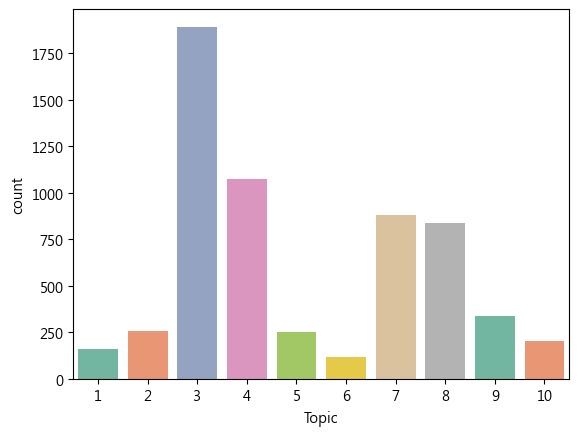

In [109]:
sns.countplot(data=data, x='Topic', palette='Set2')

In [110]:
from sklearn.manifold import TSNE

<Axes: xlabel='x', ylabel='y'>

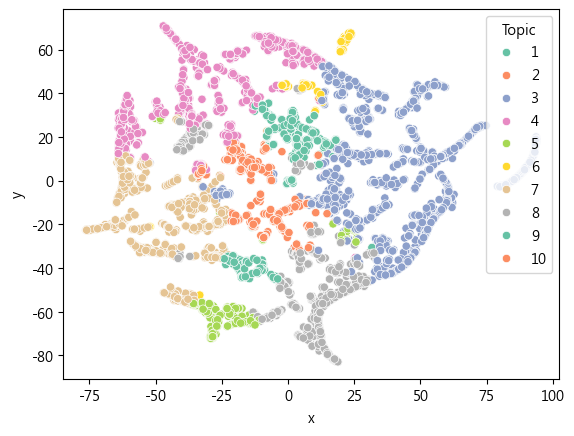

In [111]:
tsne = TSNE(n_components=2, random_state=42)
lda_tsne = tsne.fit_transform(lda_matrix)
tsne_df = pd.DataFrame(lda_tsne, columns=['x', 'y'])
tsne_df['Topic'] = data['Topic']

sns.scatterplot(data=tsne_df, x='x', y='y', hue='Topic', palette='Set2')

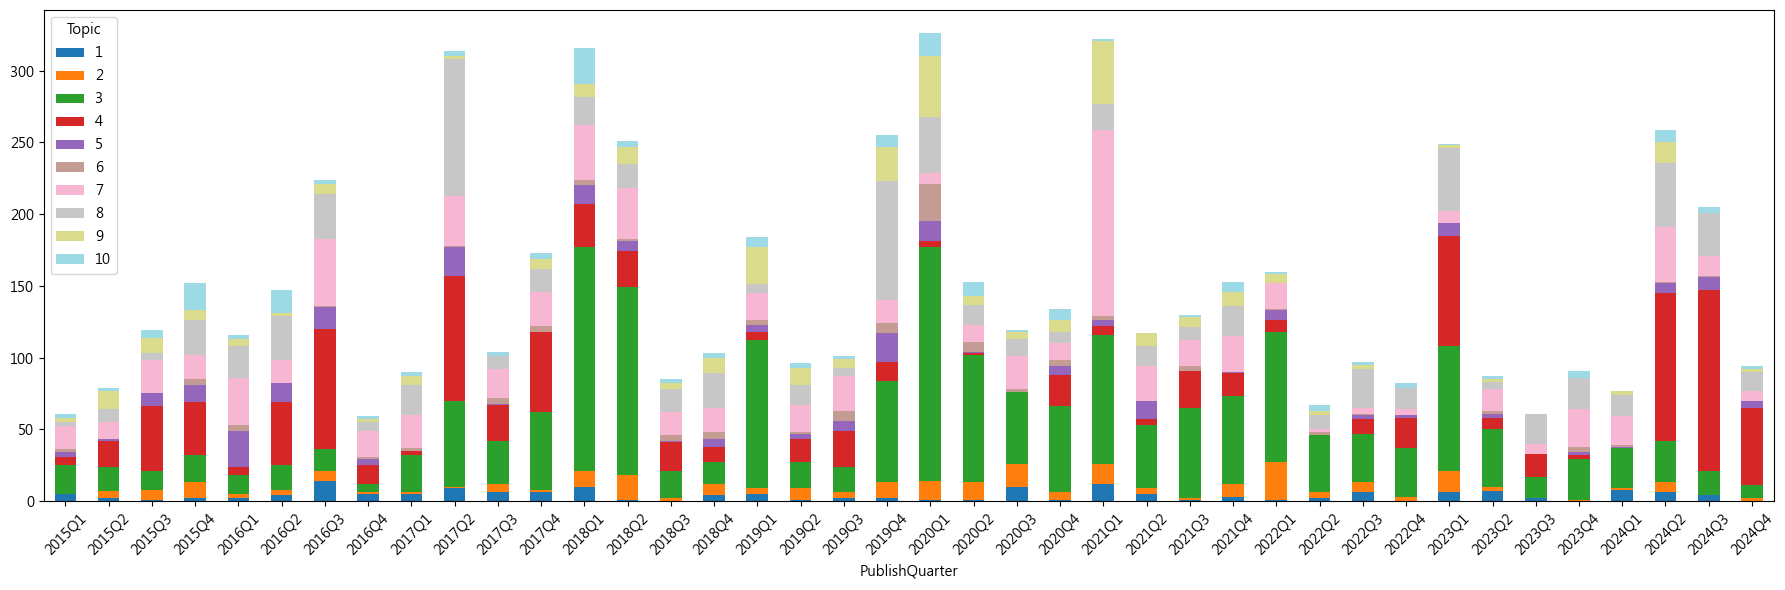

In [112]:
topic_quarter = data.groupby(['PublishQuarter', 'Topic']).size().unstack(fill_value=0)

topic_quarter.plot(kind='bar', stacked=True, colormap='tab20', figsize=(18, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

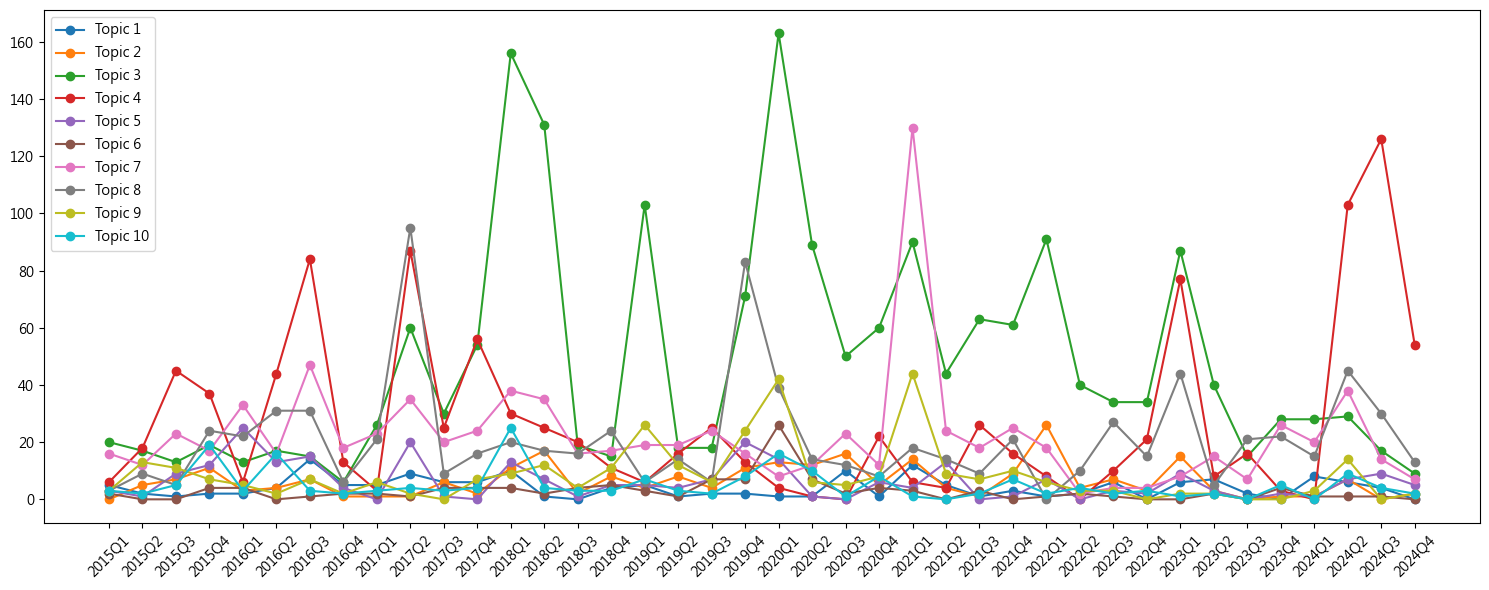

In [113]:
all_quarters = sorted(data['PublishQuarter'].unique())

plt.figure(figsize=(15, 6))
for topic in sorted(data['Topic'].unique()):
    topic_group = data[data['Topic'] == topic].groupby('PublishQuarter').size()
    topic_group = topic_group.reindex(all_quarters, fill_value=0)
    plt.plot(all_quarters, topic_group, marker='o', label=f'Topic {topic}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
# 取得所有詞彙（對應每一欄）
terms = vectorizer.get_feature_names_out()

# 建立詞頻 DataFrame：每列為一篇文章
df_count = pd.DataFrame(count_matrix.toarray(), columns=terms)

df_count.head()


,aapme,aav,ab,abc,abcd,able,about,above,abs,ac,...,龜裂,龜裂警,龜記,龜車,龜速,龜速前,龜速灑,龜速行,龜速車,龜首
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
n_topics = lda.n_components  # 主題數
topic_cols = [f'Topic {i}' for i in range(n_topics)]

df_lda = pd.DataFrame(lda_matrix, columns=topic_cols)

# 顯示前幾篇的主題機率
df_lda.head()


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9
0,0.000848,0.000848,0.000848,0.000848,0.000848,0.000847,0.992372,0.000848,0.000848,0.000848
1,0.000443,0.000443,0.000443,0.608693,0.000443,0.042488,0.121544,0.000443,0.000443,0.224619
2,0.000588,0.000588,0.279622,0.715671,0.000589,0.000588,0.000588,0.000588,0.000588,0.000588
3,0.000513,0.000513,0.000513,0.560716,0.000513,0.000513,0.142738,0.061570,0.231898,0.000513
4,0.000490,0.307949,0.000490,0.432260,0.000490,0.000490,0.000490,0.256359,0.000490,0.000490
